# DQN Pairs Trading
OLS beta · custom gym · PyTorch DQN

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random
import math
from collections import deque
from pathlib import Path

import torch
import torch.nn as nn
import torch.optim as optim
from pairs_trading_env_tc_newstate import PairsTradingEnv

# ── paste or import your env ──────────────────────────────────────────
# from pairs_trading_env import PairsTradingEnv
# If the file is in the same directory just uncomment the line above.
# Otherwise the full class is expected to be available as PairsTradingEnv.
# ─────────────────────────────────────────────────────────────────────
# 210 3 for 0.8 3,2 for 0.6 200x100 windows for 0.6 is very good; seed 11 for 400x100 for 0.5;;;;; seed 49 BROOO until 0.7, tc*5
SEED = 58
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', DEVICE)

device: cpu


## 1 · Load data & compute OLS beta

length: 745689
OLS  alpha=-1.8505  beta=1.1340
Spread  mean=-1.7882  std=0.6697


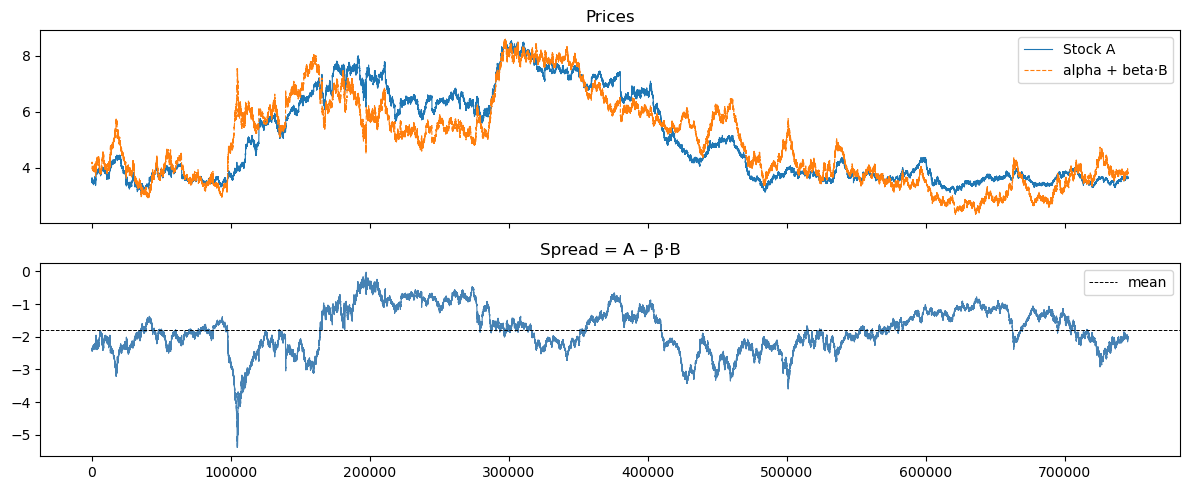

In [11]:
TRAIN_RATIO  = 0.80
# ── paths ─────────────────────────────────────────────────────────────
CSV_A = '../dataset/CORN_USD_2005_2020.csv'   # ← change to your file
CSV_B = '../dataset/WHEAT_USD_2005_2020.csv'   # ← change to your file
CSV_C = '../data-scripts/data_one_regime.csv'

CSV_D = '../dataset/WHEAT_USD_other_2005_2020.csv'
CSV_E = '../dataset/SOYBN_USD_other_2005_2020.csv'
# ─────────────────────────────────────────────────────────────────────

df_a = pd.read_csv(CSV_A).dropna()
df_b = pd.read_csv(CSV_B).dropna()

# df_a = pd.read_csv(CSV_D).dropna()
# df_b = pd.read_csv(CSV_E).dropna()

# df_a = pd.read_csv(CSV_C)[['s1']].dropna()
# df_b = pd.read_csv(CSV_C)[['s2']].dropna()
# df_a = df_a.rename(columns={"s1": "close"})
# df_b = df_b.rename(columns={"s2": "close"})

# import yfinance as yf
# df_a = yf.download("EOG", period="max", multi_level_index=False)[["Close"]].rename(columns={"Close": "close"})
# df_b = yf.download("XOM", period="max", multi_level_index=False)[["Close"]].rename(columns={"Close": "close"})
# start = max(df_a.index.min(), df_b.index.min())
# df_a, df_b = df_a.loc[start:], df_b.loc[start:]


df_a = df_a[int(0.2*len(df_a)):int(0.9*len(df_a))]
df_b = df_b[int(0.2*len(df_b)):int(0.9*len(df_b))]
n = len(df_a)
print(f"length: {n}")
# ── OLS: A = alpha + beta·B  →  beta = cov(A,B) / var(B) ────────────
A = df_a['close'].values
B = df_b['close'].values

split        = int(n * TRAIN_RATIO)
X = np.column_stack([np.ones(split), B[:split]])
beta_ols, _ = np.linalg.lstsq(X, A[:split], rcond=None)[0], None
alpha_ols = beta_ols[0]
beta      = beta_ols[1]
print(f'OLS  alpha={alpha_ols:.4f}  beta={beta:.4f}')

spread = A - beta * B
print(f'Spread  mean={spread.mean():.4f}  std={spread.std():.4f}')

fig, axes = plt.subplots(2, 1, figsize=(12, 5), sharex=True)
axes[0].plot(A, label='Stock A', linewidth=0.8)
axes[0].plot(beta * B + alpha_ols, label=f'alpha + beta·B', linewidth=0.8, linestyle='--')
axes[0].legend(); axes[0].set_title('Prices')
axes[1].plot(spread, linewidth=0.8, color='steelblue')
axes[1].axhline(spread.mean(), color='k', linestyle='--', linewidth=0.7, label='mean')
axes[1].set_title('Spread = A – β·B'); axes[1].legend()
plt.tight_layout(); plt.show()

## 2 · Train / test split

In [12]:

df_a_train, df_b_train = df_a.iloc[:split], df_b.iloc[:split]
df_a_test,  df_b_test  = df_a.iloc[split:].reset_index(drop=True), \
                          df_b.iloc[split:].reset_index(drop=True)

print(f'Train bars: {split}   Test bars: {n - split}')

Train bars: 596551   Test bars: 149138


## 3 · DQN components

In [13]:
# ── Hyper-parameters ──────────────────────────────────────────────────
TRANSACTION_COST = 0.0001     # flat cost per open / close
INITIAL_CASH     = 100.0

GAMMA            = 0.995    # discount factor
LR               = 1e-3    # learning rate
BATCH_SIZE       = 64
MEMORY_SIZE      = 50_000
TARGET_UPDATE    = 200     # steps between target-net syncs
N_EPISODES       = 400     # training episodes (each = full train series)

EPS_START        = 1.00
EPS_END          = 0.02
EPS_DECAY        = 0.994   # per-episode multiplicative decay
# ─────────────────────────────────────────────────────────────────────

STATE_DIM  = PairsTradingEnv.STATE_DIM   # 4
N_ACTIONS  = PairsTradingEnv.N_ACTIONS   # 3


# ── Q-Network ─────────────────────────────────────────────────────────
class QNet(nn.Module):
    def __init__(self, state_dim: int, n_actions: int, hidden: int = 128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(state_dim, hidden), nn.ReLU(),
            nn.Linear(hidden, hidden),    nn.ReLU(),
            nn.Linear(hidden, n_actions),
        )

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)


# ── Replay buffer ─────────────────────────────────────────────────────
class ReplayBuffer:
    def __init__(self, capacity: int):
        self.buf = deque(maxlen=capacity)

    def push(self, s, a, r, s2, done):
        self.buf.append((s, a, r, s2, done))

    def sample(self, batch_size: int):
        batch = random.sample(self.buf, batch_size)
        s, a, r, s2, d = zip(*batch)
        return (
            torch.tensor(np.array(s),  dtype=torch.float32, device=DEVICE),
            torch.tensor(a,            dtype=torch.long,    device=DEVICE),
            torch.tensor(r,            dtype=torch.float32, device=DEVICE),
            torch.tensor(np.array(s2), dtype=torch.float32, device=DEVICE),
            torch.tensor(d,            dtype=torch.float32, device=DEVICE),
        )

    def __len__(self): return len(self.buf)


# ── DQN agent ─────────────────────────────────────────────────────────
class DQNAgent:
    def __init__(self):
        self.policy_net = QNet(STATE_DIM, N_ACTIONS).to(DEVICE)
        self.target_net = QNet(STATE_DIM, N_ACTIONS).to(DEVICE)
        self.target_net.load_state_dict(self.policy_net.state_dict())
        self.target_net.eval()

        self.optimizer = optim.Adam(self.policy_net.parameters(), lr=LR)
        self.memory    = ReplayBuffer(MEMORY_SIZE)
        self.steps     = 0
        self.epsilon   = EPS_START

    # ε-greedy selection
    def select_action(self, state: np.ndarray) -> int:
        if random.random() < self.epsilon:
            return random.randint(0, N_ACTIONS - 1)
        with torch.no_grad():
            t = torch.tensor(state, dtype=torch.float32, device=DEVICE).unsqueeze(0)
            return int(self.policy_net(t).argmax(dim=1).item())

    def learn(self):
        if len(self.memory) < BATCH_SIZE:
            return

        s, a, r, s2, done = self.memory.sample(BATCH_SIZE)

        # Current Q values
        q_vals = self.policy_net(s).gather(1, a.unsqueeze(1)).squeeze(1)

        # Double-DQN target
        with torch.no_grad():
            best_actions = self.policy_net(s2).argmax(dim=1, keepdim=True)
            q_next       = self.target_net(s2).gather(1, best_actions).squeeze(1)
            target       = r + GAMMA * q_next * (1 - done)

        loss = nn.SmoothL1Loss()(q_vals, target)
        self.optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(self.policy_net.parameters(), 1.0)
        self.optimizer.step()

        self.steps += 1
        if self.steps % TARGET_UPDATE == 0:
            self.target_net.load_state_dict(self.policy_net.state_dict())

    def decay_epsilon(self):
        self.epsilon = max(EPS_END, self.epsilon * EPS_DECAY)

## 4 · Training loop

In [ ]:
def make_train_env():
    return PairsTradingEnv(
        df_a_train, df_b_train,
        beta            = beta,
        operation_penalty = TRANSACTION_COST*10,
        initial_cash    = INITIAL_CASH,
    )

agent      = DQNAgent()
train_env  = make_train_env()

ep_returns = []

for ep in range(1, N_EPISODES + 1):
    obs  = train_env.reset()
    done = False
    ep_reward = 0.0
    cntt = 0
    while not done:
        action            = agent.select_action(obs)
        obs2, reward, done, _ = train_env.step(action)
        agent.memory.push(obs, action, reward, obs2, float(done))
        if cntt % 64 == 0:
            agent.learn()
        cntt += 1
        # agent.learn()
        ep_reward += reward
        obs        = obs2

    agent.decay_epsilon()
    ep_returns.append(ep_reward)

    if ep % 10 == 0:
        recent = np.mean(ep_returns[-10:])
        print(f'Episode {ep:4d}/{N_EPISODES}  '
              f'return={ep_reward:+8.3f}  '
              f'avg10={recent:+8.3f}  '
              f'ε={agent.epsilon:.3f}  '
              f'mem={len(agent.memory)}')

print('Training complete.')

Episode   10/400  return= -98.684  avg10= -98.790  ε=0.942  mem=50000
Episode   20/400  return= -98.588  avg10= -98.705  ε=0.887  mem=50000


KeyboardInterrupt: 

### Training curves

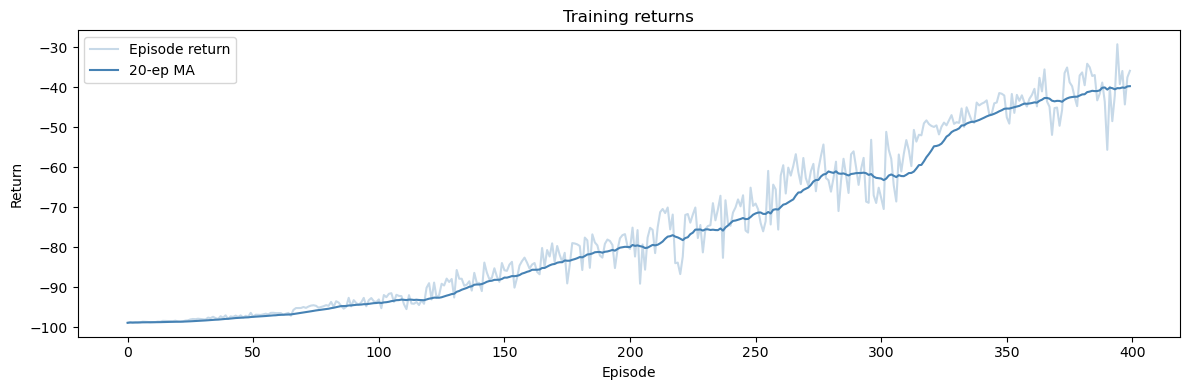

In [ ]:
window = 20
roll   = pd.Series(ep_returns).rolling(window, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax1.plot(ep_returns, alpha=0.3, color='steelblue', label='Episode return')
ax1.plot(roll,       color='steelblue', linewidth=1.5, label=f'{window}-ep MA')
ax1.set_ylabel('Return')
ax1.legend(loc='upper left')


ax1.set_title('Training returns'); ax1.set_xlabel('Episode')
plt.tight_layout(); plt.show()

## 5 · Evaluation on test set

In [ ]:
def run_episode(env: PairsTradingEnv, agent: DQNAgent, greedy: bool = True):
    """Run one episode; return per-step info dicts."""
    obs  = env.reset(is_test=True)
    done = False
    log  = []

    # Freeze epsilon for greedy evaluation
    saved_eps = agent.epsilon
    if greedy:
        agent.epsilon = 0.0

    while not done:
        action = agent.select_action(obs)
        obs, reward, done, info = env.step(action)
        info['action'] = action
        info['reward'] = reward
        log.append(info)

    agent.epsilon = saved_eps
    return pd.DataFrame(log)

test_env = PairsTradingEnv(
    df_a_test, df_b_test,
    beta            = beta,
    operation_penalty= TRANSACTION_COST,
    initial_cash    = INITIAL_CASH,
    df_a_train = df_a_train,
    df_b_train = df_b_train
)

log = run_episode(test_env, agent, greedy=True)

total_return = log['portfolio_value'].iloc[-1] - INITIAL_CASH
total_trades = (log['action'] != 1).sum()   # rough: non-HOLD steps
print(f'Test  total P&L : {total_return:+.4f}')
print(f'Test  final value: {log["portfolio_value"].iloc[-1]:.4f}')
print(f'Test  realized PnL: {log["realized_pnl"].iloc[-1]:+.4f}')
print(f'Test  non-hold steps: {total_trades}')

Test  total P&L : +11.7342
Test  final value: 111.7342
Test  realized PnL: +11.7342
Test  non-hold steps: 79023


### Test plots

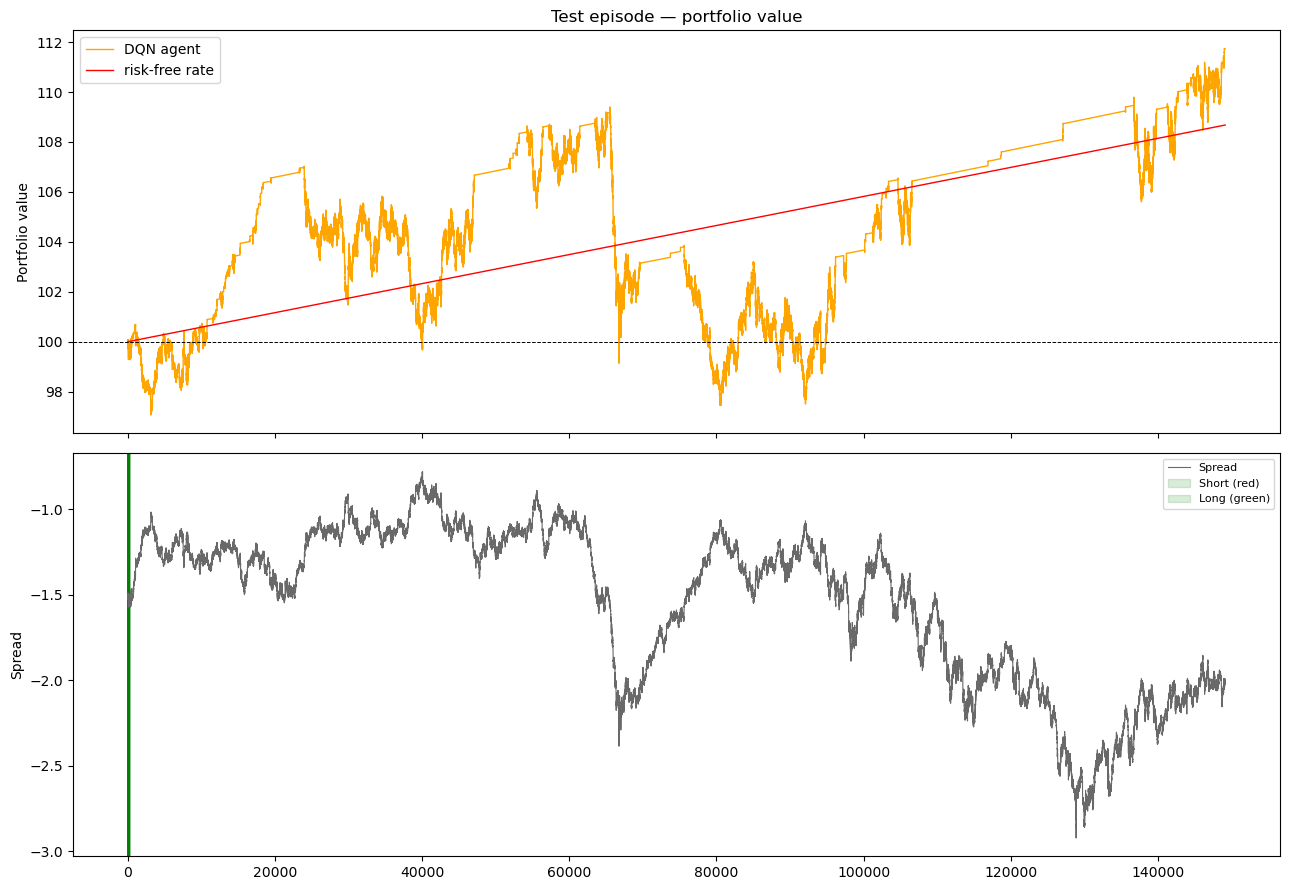

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(13, 9), sharex=True)

# ── Portfolio value ───────────────────────────────────────────────────
ax = axes[0]
ax.plot(log['portfolio_value'], color='orange', linewidth=1, label='DQN agent')
ax.plot(np.linspace(100, 100*(1.000000558**len(log['portfolio_value'])),len(log['portfolio_value'])), color='red', linewidth=1, label='risk-free rate')
ax.axhline(INITIAL_CASH, color='k', linestyle='--', linewidth=0.7)
ax.set_ylabel('Portfolio value')
ax.set_title('Test episode — portfolio value')
ax.legend()

# ── Spread + z-score + position shading ──────────────────────────────
ax = axes[1]
ax.plot(log['spread'], color='dimgray', linewidth=0.8, label='Spread')

# shade long / short periods
pos = log['position'][:100].values
for i in range(len(pos)):
    if pos[i] == 1:
        ax.axvspan(i, i + 1, alpha=0.15, color='green')
    elif pos[i] == -1:
        ax.axvspan(i, i + 1, alpha=0.15, color='red')

ax.set_ylabel('Spread')
ax.legend(['Spread', 'Short (red)', 'Long (green)'], fontsize=8)

plt.tight_layout()
plt.show()

In [ ]:
# Simpler version
returns = log['portfolio_value'].pct_change().dropna()
sharpe_ratio = (returns.mean() / returns.std()) * np.sqrt(67800)

print(f"Annualized Sharpe Ratio: {sharpe_ratio:.4f}")

Annualized Sharpe Ratio: 0.5582
